In [1]:
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             52 bits physical, 57 bits virtual
  Byte Order:                Little Endian
CPU(s):                      192
  On-line CPU(s) list:       0-191
Vendor ID:                   AuthenticAMD
  Model name:                AMD EPYC 9684X 96-Core Processor
    CPU family:              25
    Model:                   17
    Thread(s) per core:      1
    Core(s) per socket:      96
    Socket(s):               2
    Stepping:                2
    Frequency boost:         enabled
    CPU(s) scaling MHz:      69%
    CPU max MHz:             3715.4290
    CPU min MHz:             1500.0000
    BogoMIPS:                5099.89
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ht s
                             yscall nx mmxext fxsr_opt pdpe1gb rdtscp lm constan
                         

In [2]:
import numpy as np
import pickle
import time
import glob

import sys
sys.path.insert(0, "../..")
from shared import load_sweep_data, run_param_recovery, plot_param_estimate, setup_latex_matplotlib

In [3]:
import warnings

warnings.filterwarnings(
    "ignore",
    message=r"delta_grad == 0\.0\. Check if the approximated function is linear\..*",
    category=UserWarning,
)

In [4]:
all_data, data_keys = load_sweep_data("eta")

Loaded 21 eta values from addm_data_all_eta_20260206-174356.pkl


In [5]:
num_data_list = [100, 200, 400, 800, 1600, 3200, 6400, 12800, 25600]

### Run maximum likelihood with aDDM likelihood function with different dataset size

In [6]:
paras_true, paras_mle = run_param_recovery(all_data, num_data_list, mode="mle")

true params: [0.00, 0.50, 2.00, 0.50]
num_data:   100, mle: [0.00569, 0.54060, 1.86890, 0.31675]
num_data:   200, mle: [0.03570, 0.49902, 1.89694, 0.44828]
num_data:   400, mle: [0.07326, 0.50419, 1.96729, 0.50401]
num_data:   800, mle: [0.03641, 0.50309, 1.98647, 0.49968]
num_data:  1600, mle: [0.01065, 0.50524, 2.00978, 0.52054]
num_data:  3200, mle: [0.00740, 0.50432, 2.01026, 0.51387]
num_data:  6400, mle: [0.01165, 0.50407, 2.00120, 0.50414]
num_data: 12800, mle: [0.00882, 0.50417, 2.00599, 0.50825]
num_data: 25600, mle: [0.01134, 0.50210, 2.00378, 0.50071]

true params: [0.05, 0.50, 2.00, 0.50]
num_data:   100, mle: [0.00000, 0.44211, 1.92200, 0.44577]
num_data:   200, mle: [0.00735, 0.49215, 1.99847, 0.44648]
num_data:   400, mle: [0.02064, 0.52517, 2.01040, 0.45223]
num_data:   800, mle: [0.05237, 0.50119, 1.98096, 0.46168]
num_data:  1600, mle: [0.06939, 0.50686, 2.00476, 0.48034]
num_data:  3200, mle: [0.05823, 0.51124, 2.02738, 0.50435]
num_data:  6400, mle: [0.05552, 0.5008

### Run maximum likelihood with TADA likelihood function with different dataset size

In [7]:
_, paras_tada = run_param_recovery(all_data, num_data_list, mode="tada")

true params: [0.00, 0.50, 2.00, 0.50]
num_data:   100, tada mle: [-0.08504, 0.57402, 1.80211, 0.27122]
num_data:   200, tada mle: [-0.08926, 0.55037, 1.84186, 0.40124]
num_data:   400, tada mle: [-0.07742, 0.56503, 1.92706, 0.46958]
num_data:   800, tada mle: [-0.14070, 0.59079, 1.95974, 0.47181]
num_data:  1600, tada mle: [-0.14189, 0.58166, 1.96848, 0.48632]
num_data:  3200, tada mle: [-0.15579, 0.58742, 1.97353, 0.47269]
num_data:  6400, tada mle: [-0.15110, 0.59106, 1.96775, 0.46544]
num_data: 12800, tada mle: [-0.15288, 0.59148, 1.97044, 0.46837]
num_data: 25600, tada mle: [-0.14861, 0.58767, 1.96809, 0.46166]

true params: [0.05, 0.50, 2.00, 0.50]
num_data:   100, tada mle: [-0.25560, 0.62871, 1.95722, 0.39463]
num_data:   200, tada mle: [-0.18718, 0.64719, 2.01869, 0.40793]
num_data:   400, tada mle: [-0.16742, 0.66265, 2.02931, 0.41642]
num_data:   800, tada mle: [-0.12826, 0.60258, 1.96310, 0.41933]
num_data:  1600, tada mle: [-0.11426, 0.60952, 1.99090, 0.45048]
num_data:  32

num_data: 12800, tada mle: [-0.11605, 0.58239, 1.97471, 0.46721]
num_data: 25600, tada mle: [-0.11426, 0.58343, 1.97608, 0.46956]

true params: [0.10, 0.50, 2.00, 0.50]
num_data:   100, tada mle: [0.09205, 0.52953, 1.88013, 0.39817]
num_data:   200, tada mle: [-0.01098, 0.59747, 1.96191, 0.37501]
num_data:   400, tada mle: [-0.04312, 0.59775, 1.96378, 0.42531]
num_data:   800, tada mle: [-0.06699, 0.58338, 1.97579, 0.44007]
num_data:  1600, tada mle: [-0.05361, 0.57666, 1.97455, 0.45080]
num_data:  3200, tada mle: [-0.05060, 0.57626, 1.97126, 0.47045]
num_data:  6400, tada mle: [-0.05123, 0.58095, 1.98160, 0.47319]
num_data: 12800, tada mle: [-0.05565, 0.58089, 1.97324, 0.46159]
num_data: 25600, tada mle: [-0.05665, 0.57821, 1.97145, 0.46527]

true params: [0.15, 0.50, 2.00, 0.50]
num_data:   100, tada mle: [0.06940, 0.53379, 2.01192, 0.50075]
num_data:   200, tada mle: [0.05081, 0.55306, 1.95287, 0.46681]
num_data:   400, tada mle: [0.05853, 0.57118, 1.99328, 0.45187]
num_data:   800,

In [2]:
# data_to_save = {
#     "paras_true_arr": paras_true,
#     "paras_mle_arr": paras_mle,
#     "paras_tada_arr": paras_tada,
# }
# fname = "tada_mle_result_" + time.strftime("%Y%m%d-%H%M%S") + ".pkl"
# with open(fname, "wb") as f:
#     pickle.dump(data_to_save, f)
# print(f"Saved to {fname}")

In [9]:
# # load results (if necessary)
# result_files = sorted(glob.glob("tada_mle_result_*.pkl"))
# results = pickle.load(open(result_files[-1], "rb"))
# paras_true = results["paras_true_arr"]
# paras_mle = results["paras_mle_arr"]
# paras_tada = results["paras_tada_arr"]

In [10]:
setup_latex_matplotlib()

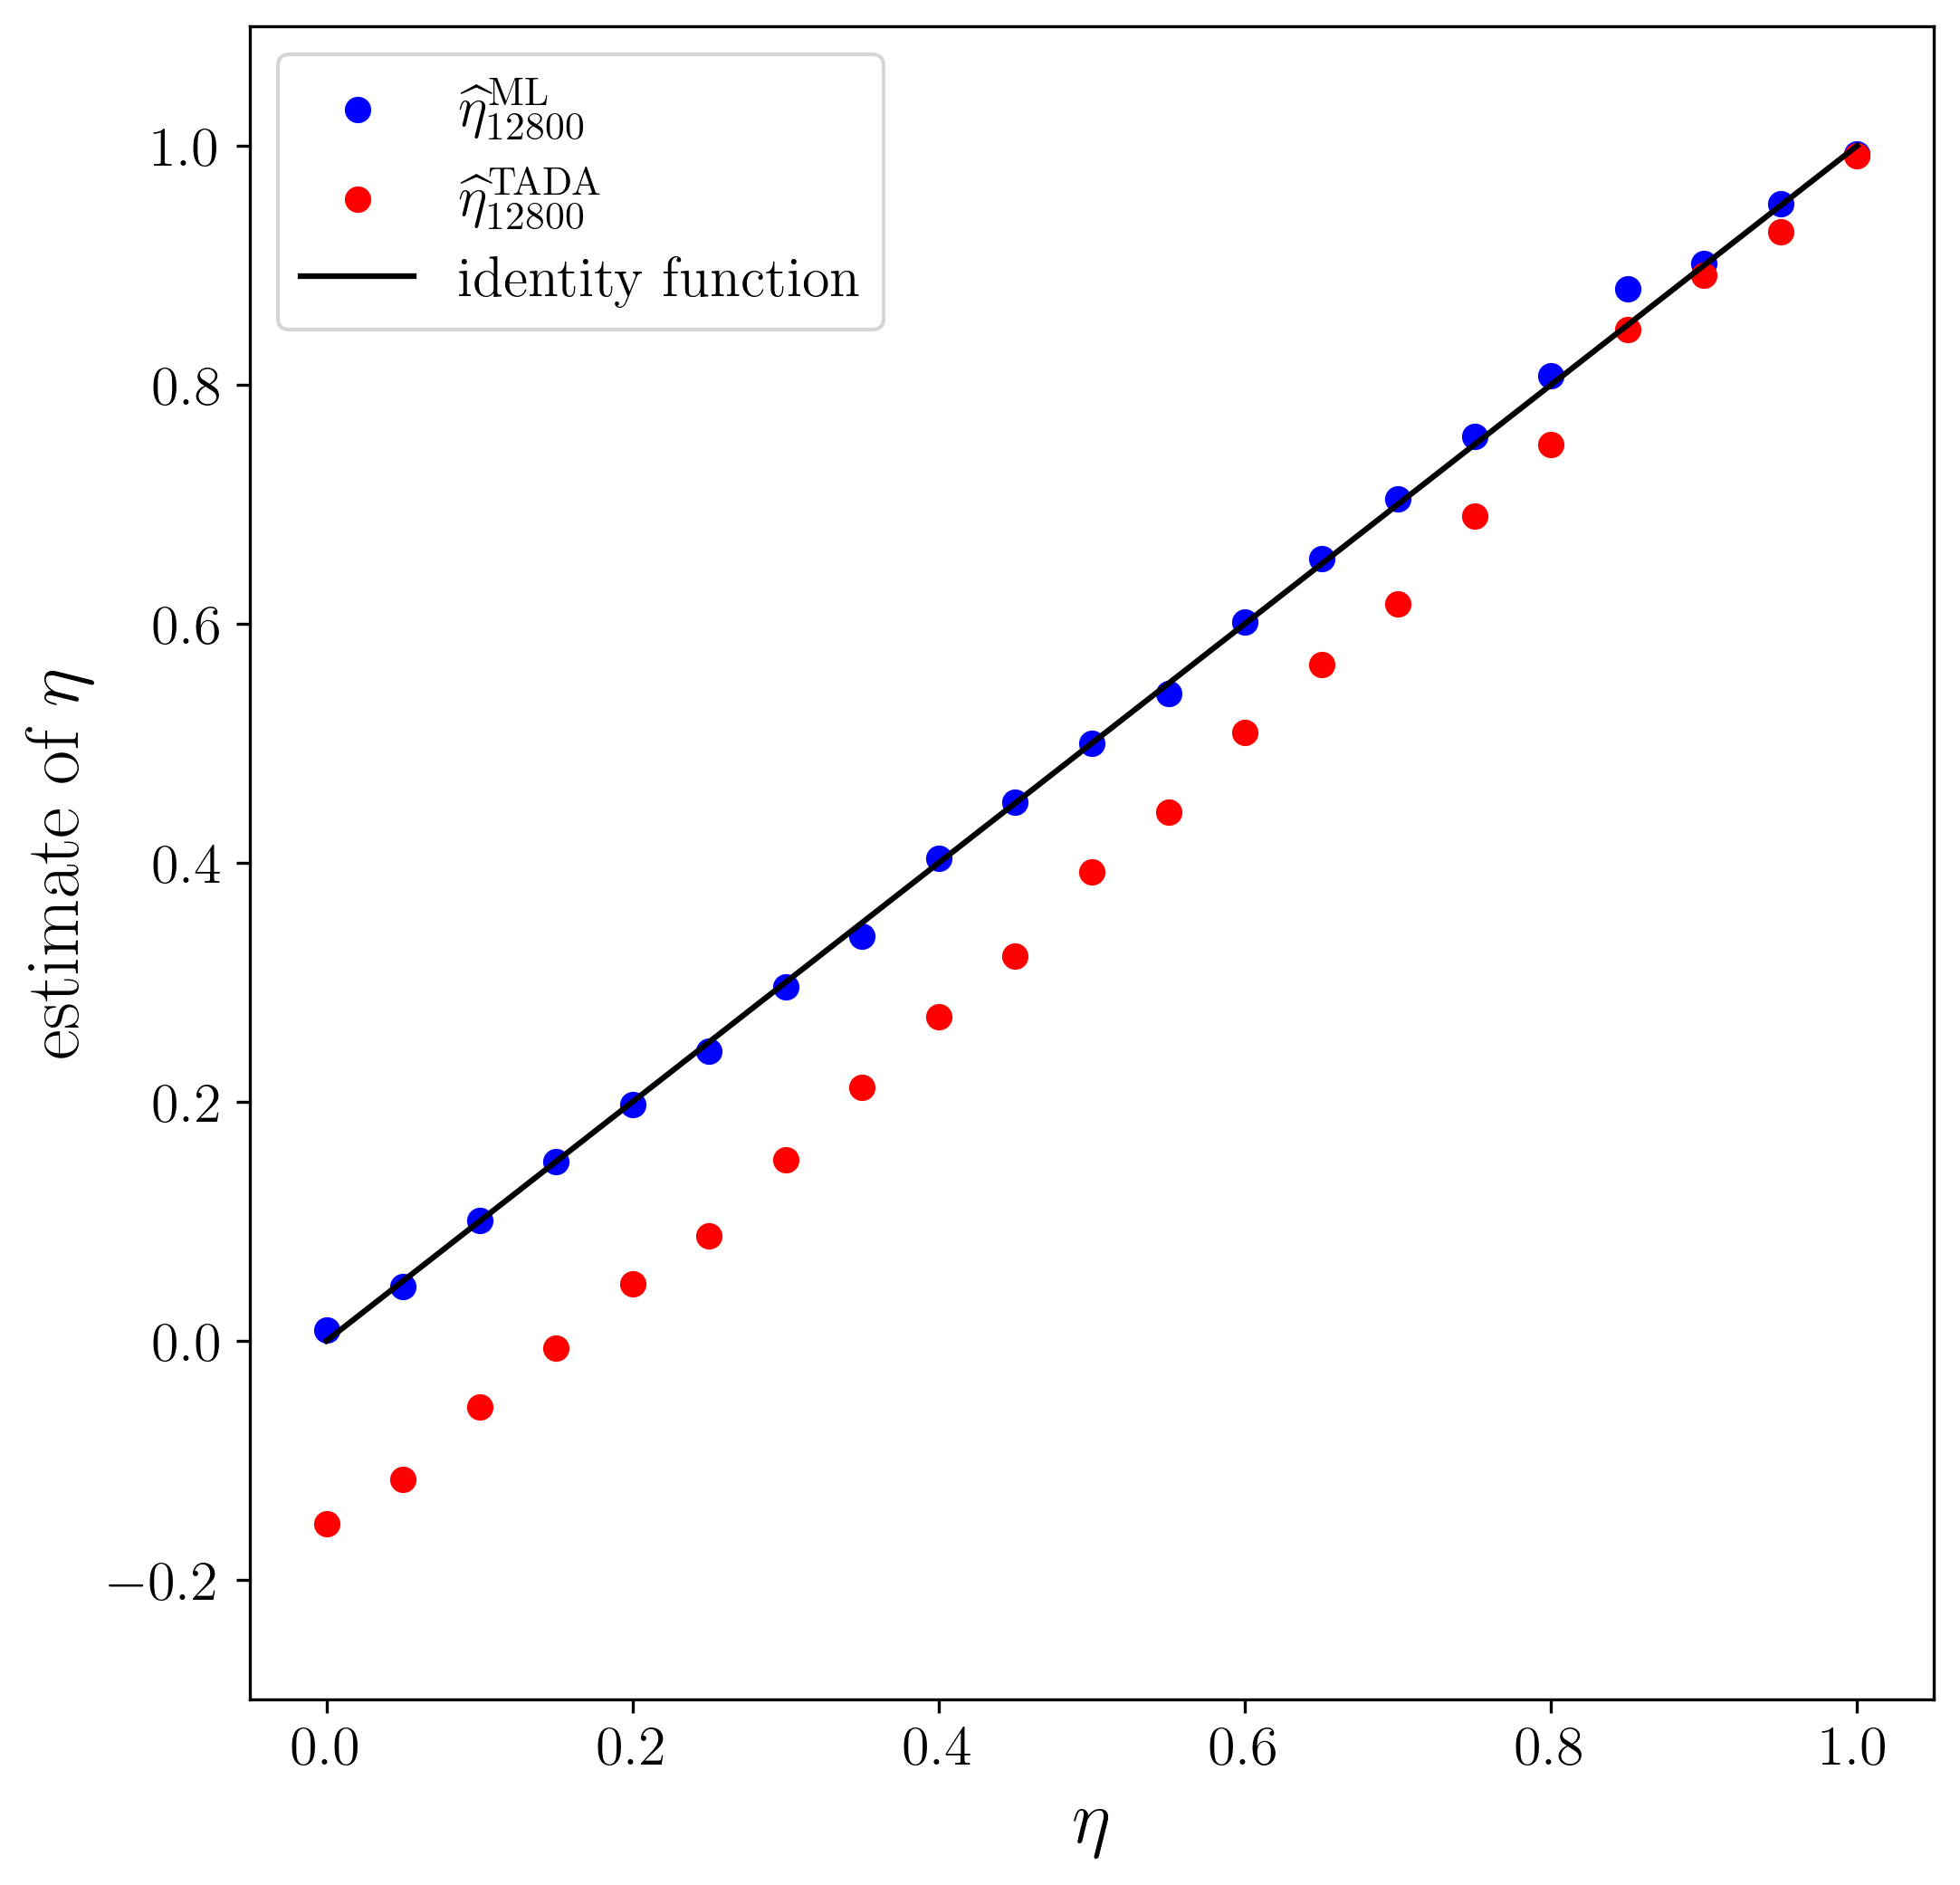

In [11]:
plot_param_estimate(
    paras_true, paras_mle, paras_tada,
    param_idx=0, param_name=r"\eta",
    swept_idx=0, swept_name=r"\eta",
    num_data_list=num_data_list,
    identity_line=True,
    xlim=(-0.05, 1.05), ylim=(-0.3, 1.1),
)

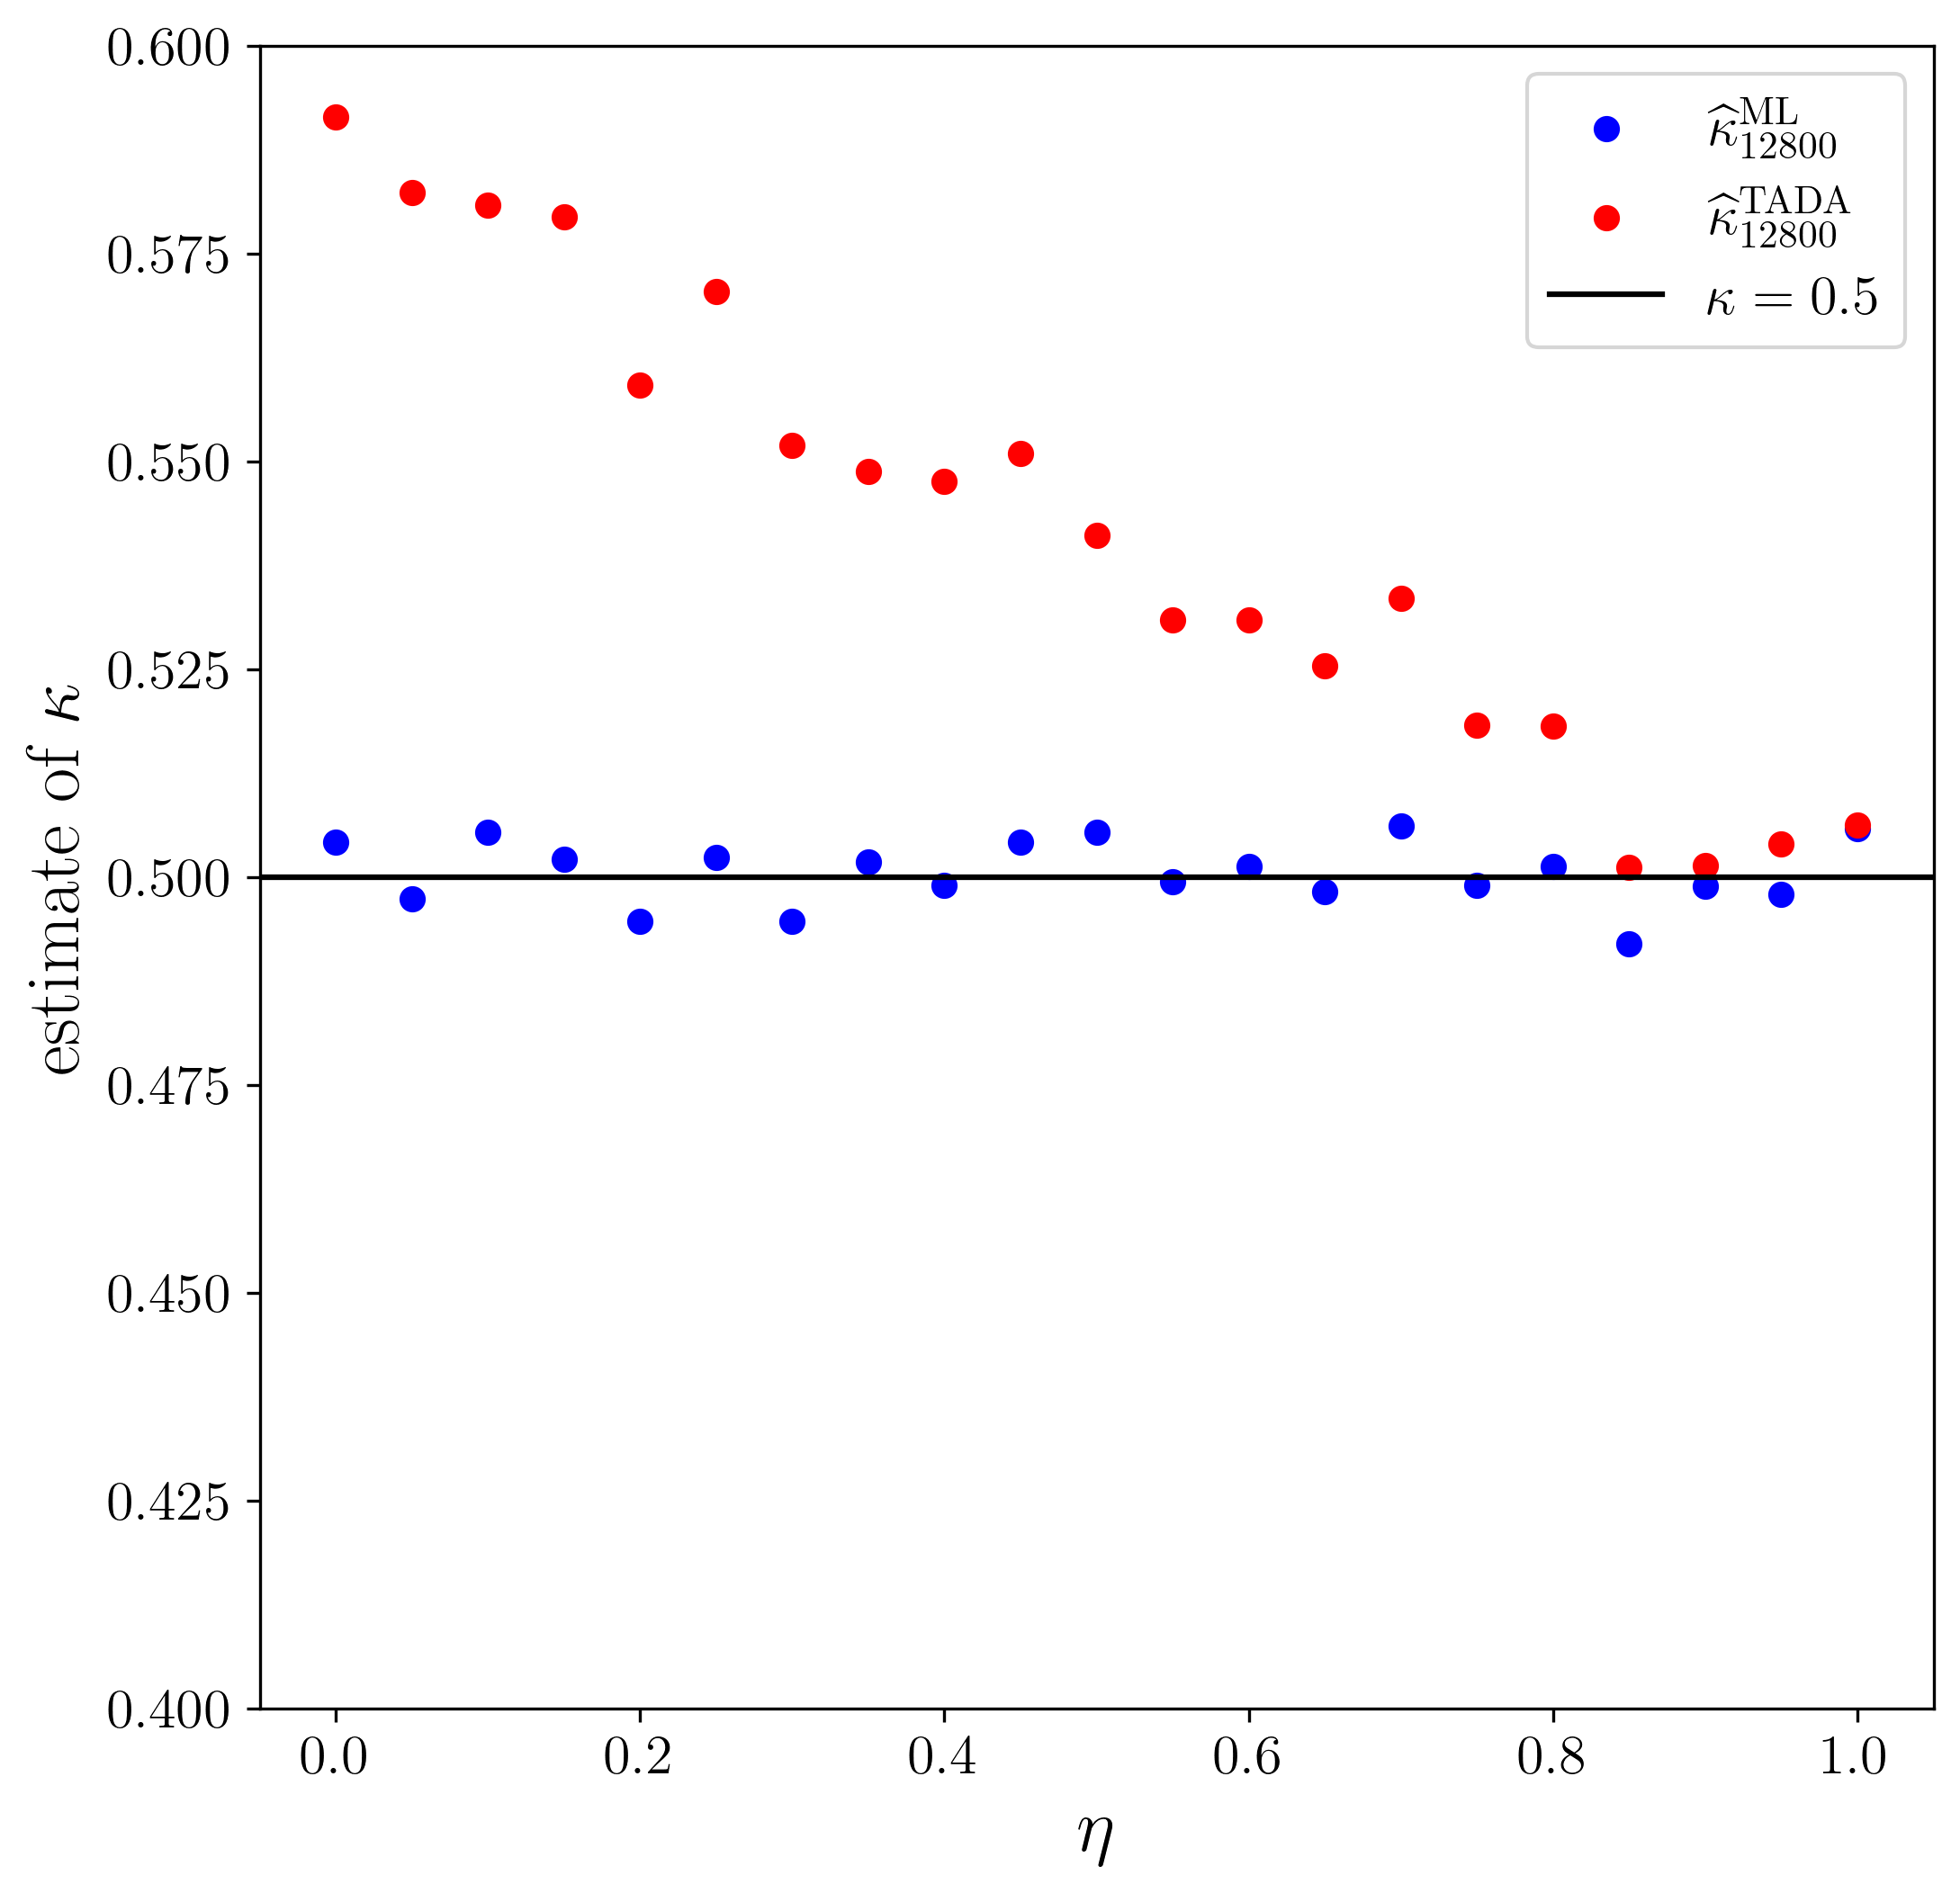

In [12]:
plot_param_estimate(
    paras_true, paras_mle, paras_tada,
    param_idx=1, param_name=r"\kappa",
    swept_idx=0, swept_name=r"\eta",
    num_data_list=num_data_list,
    horizontal_line=paras_true[-2, 0, 1],
    xlim=(-0.05, 1.05), ylim=(0.4, 0.6),
)

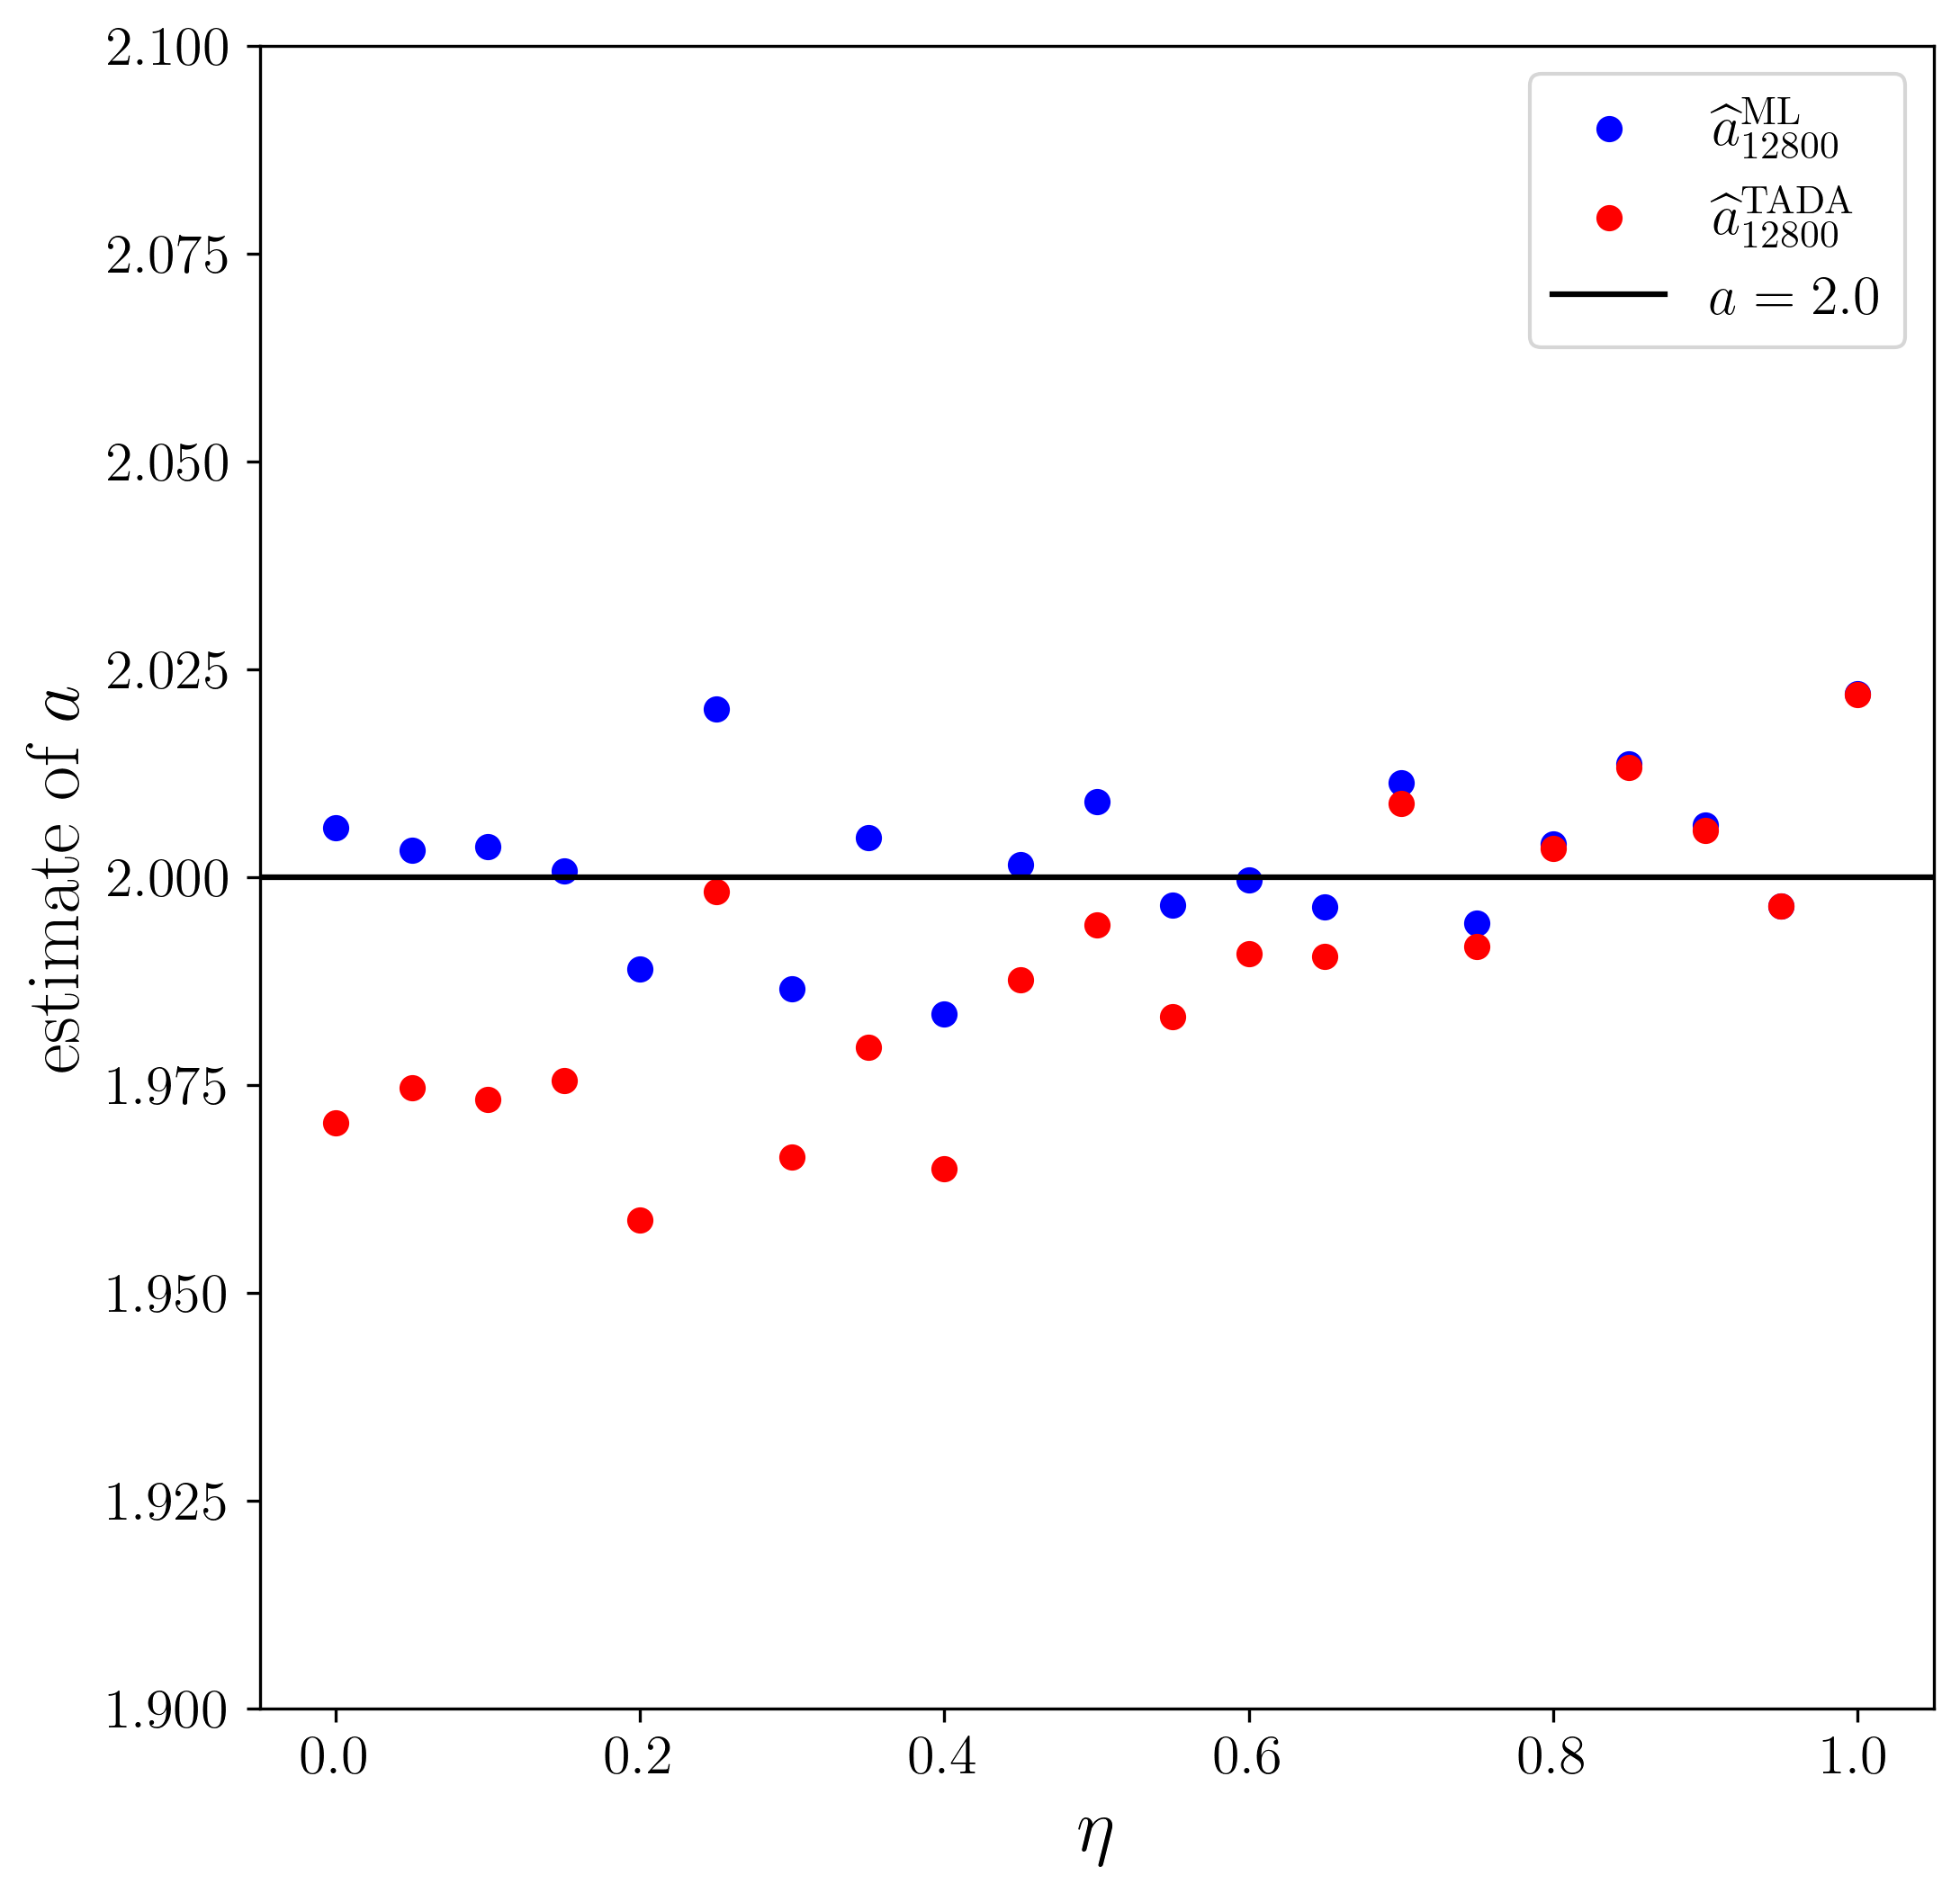

In [ ]:
plot_param_estimate(
    paras_true, paras_mle, paras_tada,
    param_idx=2, param_name=r"a",
    swept_idx=0, swept_name=r"\eta",
    num_data_list=num_data_list,
    horizontal_line=paras_true[-2, 0, 2],
    xlim=(-0.05, 1.05), ylim=(1.9, 2.1),
)

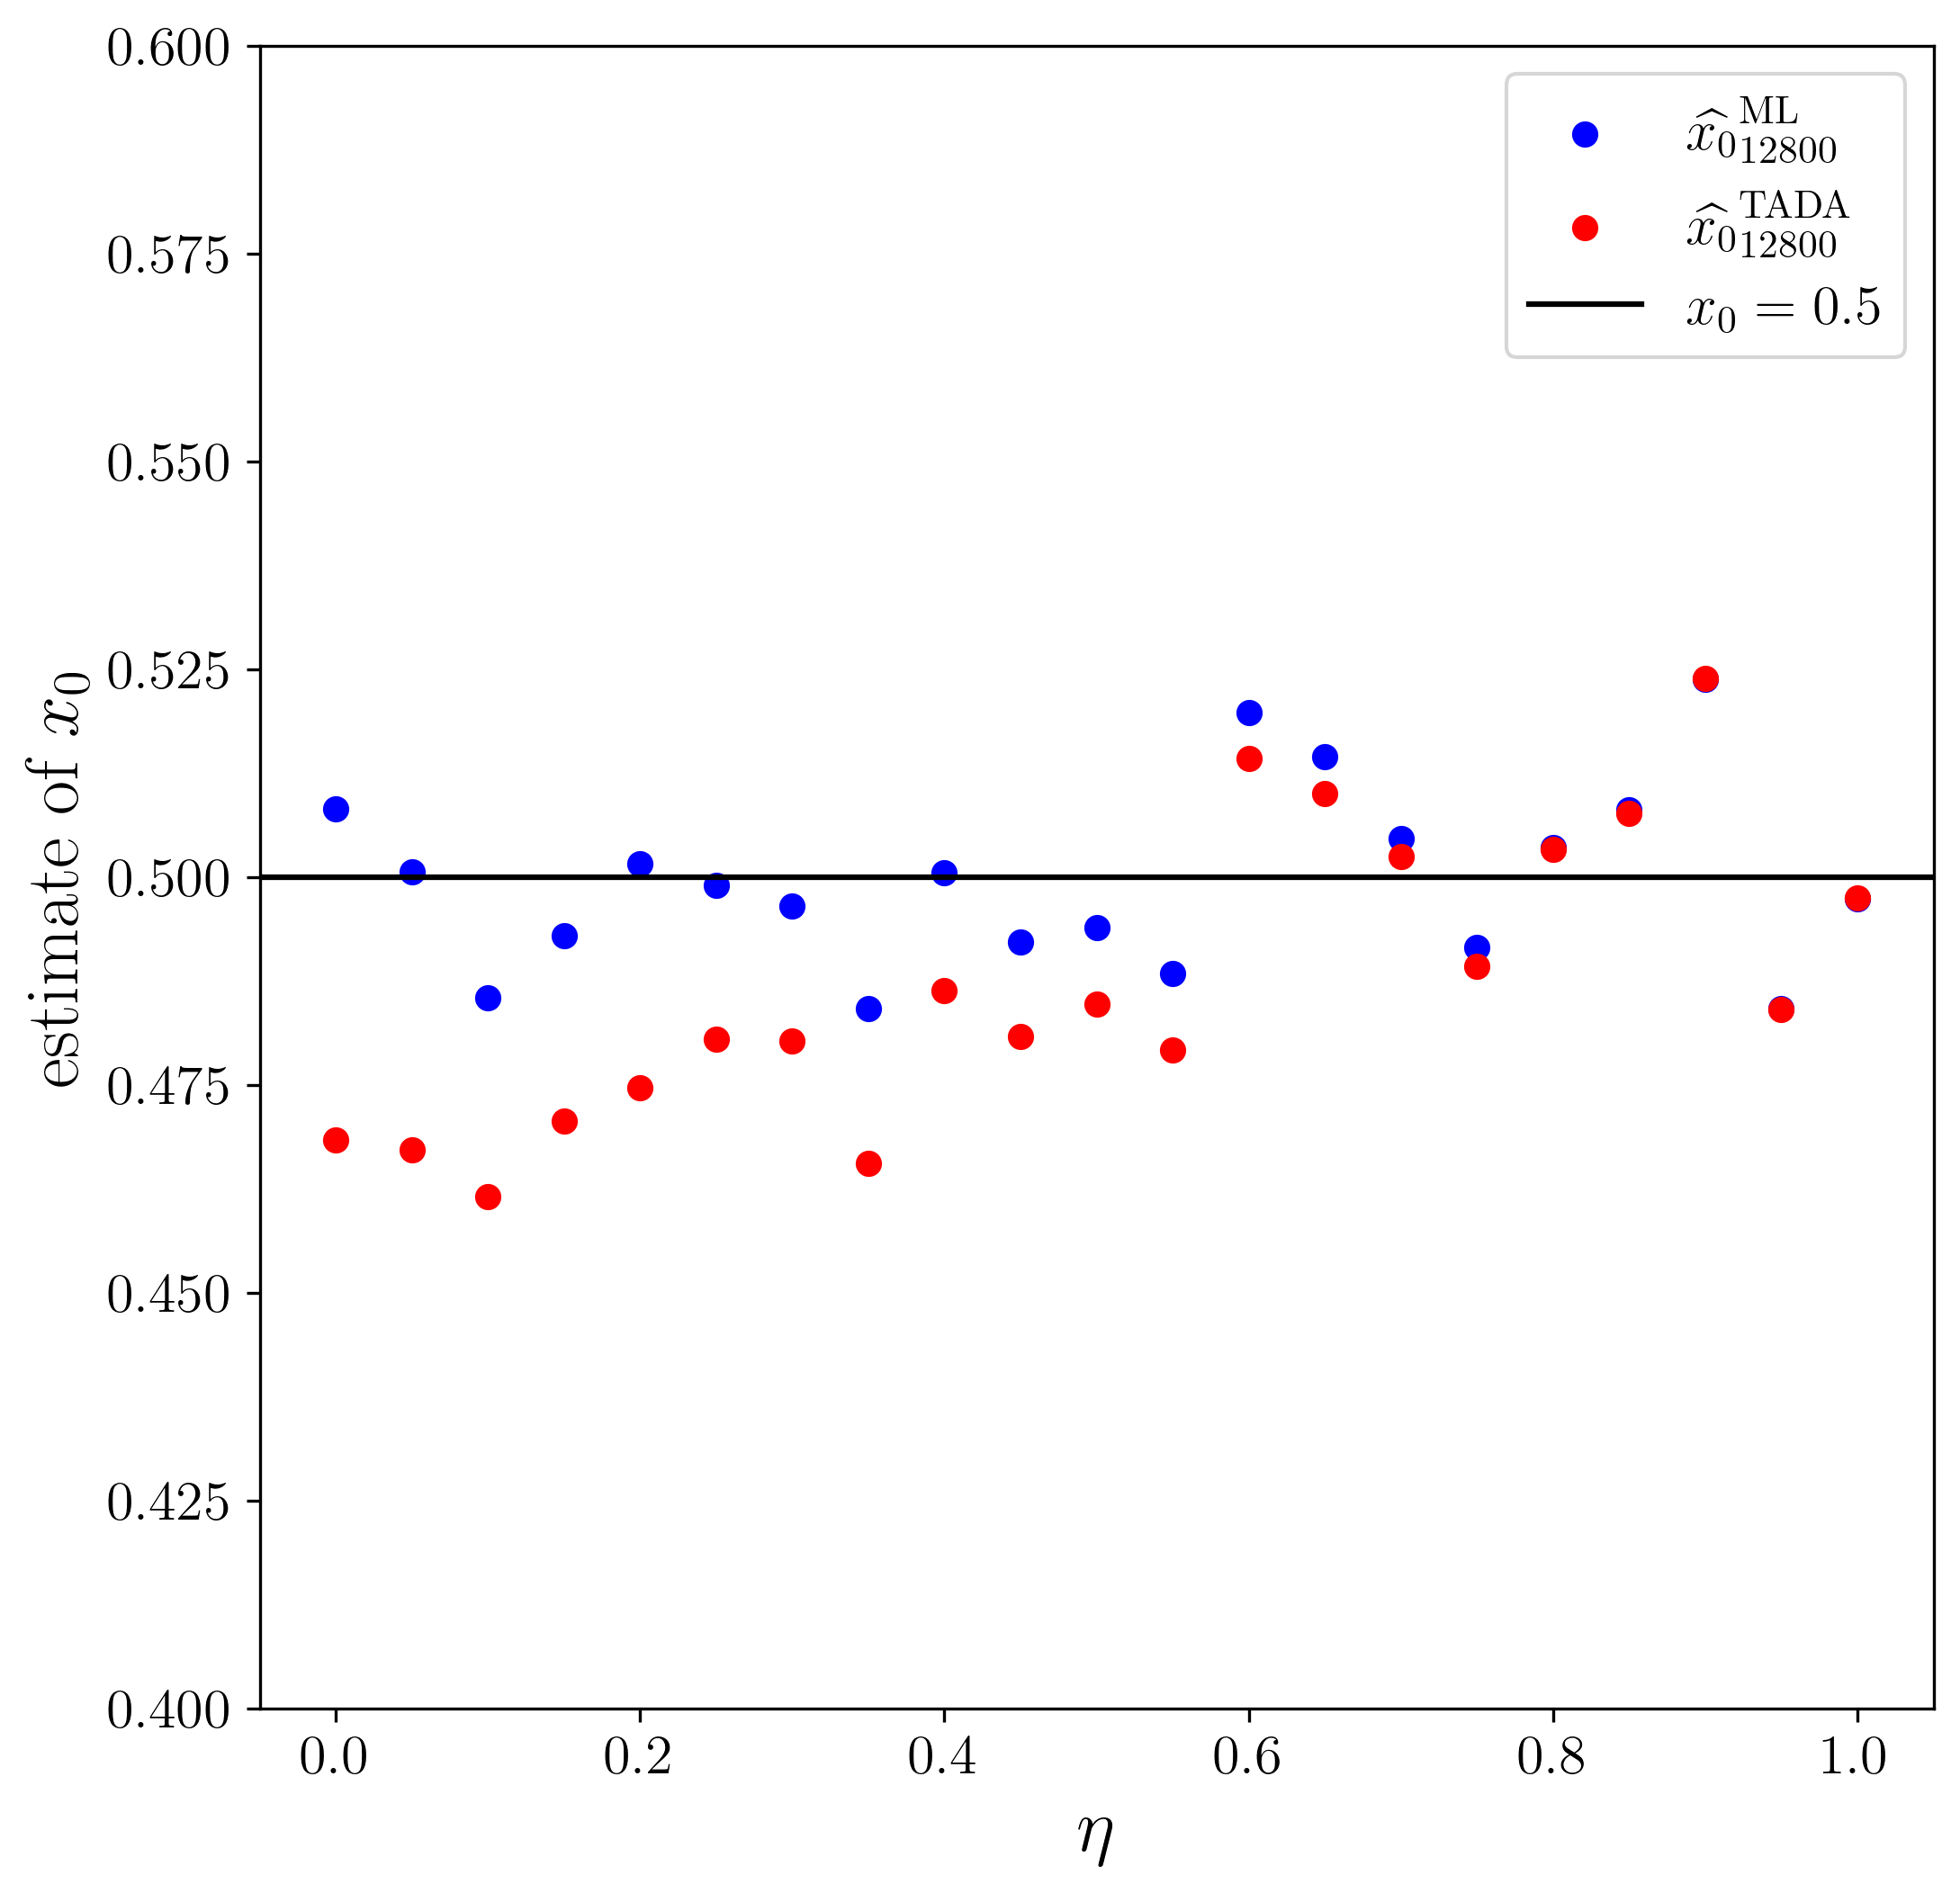

In [ ]:
plot_param_estimate(
    paras_true, paras_mle, paras_tada,
    param_idx=3, param_name=r"x_0",
    swept_idx=0, swept_name=r"\eta",
    num_data_list=num_data_list,
    horizontal_line=paras_true[-2, 0, 3],
    xlim=(-0.05, 1.05), ylim=(0.4, 0.6),
)